# REGIME-SHIFT — Stage 3: HMM Development & Validation (Isolated)
### Build and validate the regime classifier independently — no optimizer in this stage

**What this stage does (and does NOT do):**
- ✅ Runs BIC/AIC grid search → selects best n_states and covariance_type
- ✅ Aligns states by **mean realised volatility** (low vol = Bull, high vol = Crisis)
- ✅ Runs three convergence/quality checks on every fitted model
- ✅ Checks for cold-start Crisis problem in the first walk-forward fold
- ✅ Produces regime timeline — verifies 2013, 2016, 2020 crisis activations
- ✅ Demonstrates and implements `predict_proba` (forward algorithm) for test-fold decoding
- ❌ Does NOT touch CVXPY / portfolio weights — that is Stage 4

**Reads from:** `data/monthly/hmm_features_train.parquet` (Stage 1 output)  
**Saves to:** `data/stage3/`


In [1]:
import subprocess, sys
for p in ["hmmlearn>=0.3.0", "scikit-learn>=1.3.0"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("✓ Packages ready")


✓ Packages ready


In [2]:
import warnings, json, pickle
from pathlib     import Path
from itertools   import product

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")


Imports OK


In [3]:
# ══════════════════════════════════════════════════════════════════
#  Stage 3 configuration — all parameters locked before any fitting
# ══════════════════════════════════════════════════════════════════

DATA_DIR          = Path("data")
STAGE3_DIR        = DATA_DIR / "stage3"
STAGE3_DIR.mkdir(exist_ok=True)

BACKTEST_END      = "2023-12-31"
HOLDOUT_START     = "2024-01-01"

# Do not force 3 states: rolling notebooks show broad Bull/Crisis is often the
# statistically correct regime split.
GRID_N_STATES     = [2, 3, 4]
GRID_COV_TYPES    = ["full", "diag", "tied"]
FORCE_N_STATES    = None

HMM_N_INIT        = 20
HMM_N_ITER        = 500
HMM_SEED          = 42

HMM_FEATURE_COLUMNS = [
    "nifty_mom_z",
    "realized_vol_z",
    "vix_z",
    "inr_stress",
    "gsec_mom_z",
    "trend_quality_z",
]

STATE_SCORE_WEIGHTS = {
    "nifty_mom_z":        0.35,
    "trend_quality_z":    0.15,
    "realized_vol_z":    -1.00,
    "vix_z":             -0.25,
    "inr_stress":        -0.10,
    "gsec_mom_z":        -0.05,
}

RVOL_IDX           = HMM_FEATURE_COLUMNS.index("realized_vol_z")
TREND_QUALITY_IDX = HMM_FEATURE_COLUMNS.index("trend_quality_z")

MIN_LL_PER_OBS    = -20.0
MIN_VOL_RATIO     = 1.5
MIN_STATE_OBS     = 10
BULL_SHARE_RANGE  = (0.55, 0.80)

MIN_CRISIS_OBS    = 3
CRISIS_CONF_THR   = 0.70
FIRST_FOLD_END    = "2014-12-31"
TEST_START        = "2015-01-01"

print("✓ Stage 3 config loaded")
print(f"  Grid: {len(GRID_N_STATES) * len(GRID_COV_TYPES)} combinations "
      f"({GRID_N_STATES} × {GRID_COV_TYPES})")
print(f"  n_init = {HMM_N_INIT}  |  n_iter = {HMM_N_ITER}")
print(f"  FORCE_N_STATES = {FORCE_N_STATES}")
print(f"  HMM features: {HMM_FEATURE_COLUMNS}")
print(f"  Bull share target: {BULL_SHARE_RANGE[0]:.0%}-{BULL_SHARE_RANGE[1]:.0%}")
print(f"  Crisis confidence threshold: {CRISIS_CONF_THR}")


✓ Stage 3 config loaded
  Grid: 9 combinations ([2, 3, 4] × ['full', 'diag', 'tied'])
  n_init = 20  |  n_iter = 500
  FORCE_N_STATES = None
  HMM features: ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z']
  Bull share target: 55%-80%
  Crisis confidence threshold: 0.7


In [4]:
# Load ONLY training features (holdout is sealed)
feat_train_all = pd.read_parquet(DATA_DIR / "monthly" / "hmm_features_train.parquet")

missing_features = [c for c in HMM_FEATURE_COLUMNS if c not in feat_train_all.columns]
if missing_features:
    raise ValueError(f"Missing HMM feature columns from Stage 1 output: {missing_features}")

feat_train = feat_train_all[HMM_FEATURE_COLUMNS].copy()

print("✓ Feature matrix loaded")
print(f"  Available : {list(feat_train_all.columns)}")
print(f"  HMM used  : {list(feat_train.columns)}")
print(f"  Shape     : {feat_train.shape}  "
      f"({feat_train.index[0].date()} → {feat_train.index[-1].date()})")
print(f"\nNaN counts per HMM feature:")
print(feat_train.isna().sum().to_dict())
print(f"\nFeature ranges (raw, no clip):")
print(feat_train.describe().loc[["min","mean","max"]].round(2).to_string())


✓ Feature matrix loaded
  Available : ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z', 'nifty_trend_126d_z']
  HMM used  : ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z']
  Shape     : (168, 6)  (2010-01-29 → 2023-12-29)

NaN counts per HMM feature:
{'nifty_mom_z': 0, 'realized_vol_z': 0, 'vix_z': 9, 'inr_stress': 0, 'gsec_mom_z': 28, 'trend_quality_z': 0}

Feature ranges (raw, no clip):
      nifty_mom_z  realized_vol_z   vix_z  inr_stress  gsec_mom_z  trend_quality_z
min       -3.3900         -2.2200 -2.8100     -2.9600     -2.1100          -2.2400
mean      -0.0300         -0.0800 -0.1300      0.1000      0.0900           0.0200
max        2.5300          4.6300  3.6600      3.2000      2.4800           2.9900


## Section 2.1 — Feature Preparation

**No clipping in Stage 3.**  
Stage 2 used ±2.0 sigma clipping, which compressed the COVID VIX spike (+7.8 σ)  
and prevented the HMM from learning a distinct Crisis covariance structure.  
In Stage 3 we feed raw z-scores — extreme tails carry the crisis signal.


In [5]:
# ── Sigma clipping ────────────────────────────────────────────────────────────
# Features are now 12-month ROLLING z-scores (changed in Stage 1).
#
# With rolling z-score, the feature landscape is fundamentally different:
#   COVID March 2020:   realized_vol_z ≈ +3-4σ  (was +9.85σ with expanding)
#   2018 IL&FS Sep:     realized_vol_z ≈ +2.3σ  (was +1.0σ with expanding)
#   2022 rate-hike:     realized_vol_z ≈ +1.5σ  (was +0.8σ with expanding)
#   2021 bull market:   realized_vol_z ≈ −0.5σ  (was −0.4σ — correctly low)
#
# Stressed months are much closer to each other now (ratio COVID:IL&FS ≈ 1.7x
# vs 9.85x before). The HMM naturally groups them into Bear/Crisis clusters
# without clipping needing to do the heavy lifting.
#
# Clip at ±3.5σ: prevents any single month from still being so extreme that it
# consumes a full HMM state on its own. At 3.5σ, only genuine tail events are
# capped — normal market variation at ±2σ is fully preserved.
CLIP_SIGMA = 3.5

def prepare_features(features: pd.DataFrame,
                     clip_sigma: float = CLIP_SIGMA) -> tuple:
    """
    Drop months where ANY feature is NaN, then clip at ±clip_sigma.
    Clipping prevents a single extreme outlier (COVID realized_vol = +9.85σ)
    from consuming an entire HMM state, which would force everything else
    into one dominant Bull cluster.
    Returns (X_array, valid_datetime_index).
    """
    clean = features.dropna()
    X     = np.clip(clean.values, -clip_sigma, clip_sigma)
    return X, clean.index


# Full in-sample data
X_full, idx_full = prepare_features(feat_train)

n_total   = len(feat_train)
n_dropped = n_total - len(X_full)
print(f"Full training window (clip = ±{CLIP_SIGMA}σ):")
print(f"  Total months  : {n_total}")
print(f"  Dropped (NaN) : {n_dropped}  (early VIX/GSEC feature gaps)")
print(f"  Usable months : {len(X_full)}")
print(f"  Date range    : {idx_full[0].date()} → {idx_full[-1].date()}")

# Check clipping effect on key outlier
raw_clean  = feat_train.dropna()
raw_covid  = raw_clean.loc["2020-03-31"] if "2020-03-31" in raw_clean.index else raw_clean.iloc[-1]
clip_covid = np.clip(raw_covid.values, -CLIP_SIGMA, CLIP_SIGMA)
print(f"\nClipping effect on March 2020 (with rolling z-scores, expect ≈3-4σ not 9.85σ):")
for j, col in enumerate(feat_train.columns):
    raw_v  = raw_covid.iloc[j]
    clip_v = clip_covid[j]
    tag    = " ← clipped" if abs(raw_v) > CLIP_SIGMA else ""
    print(f"  {col:22s}: raw={raw_v:+.3f}  clipped={clip_v:+.3f}{tag}")

# First walk-forward fold
feat_fold1 = feat_train.loc[:FIRST_FOLD_END]
X_fold1, idx_fold1 = prepare_features(feat_fold1)
print(f"\nFirst fold (≤ {FIRST_FOLD_END}): {len(X_fold1)} usable months")
print(f"  Date range: {idx_fold1[0].date()} → {idx_fold1[-1].date()}")


Full training window (clip = ±3.5σ):
  Total months  : 168
  Dropped (NaN) : 28  (early VIX/GSEC feature gaps)
  Usable months : 140
  Date range    : 2012-05-31 → 2023-12-29

Clipping effect on March 2020 (with rolling z-scores, expect ≈3-4σ not 9.85σ):
  nifty_mom_z           : raw=-3.395  clipped=-3.395
  realized_vol_z        : raw=+4.628  clipped=+3.500 ← clipped
  vix_z                 : raw=+3.662  clipped=+3.500 ← clipped
  inr_stress            : raw=+2.241  clipped=+2.241
  gsec_mom_z            : raw=-0.537  clipped=-0.537
  trend_quality_z       : raw=-1.160  clipped=-1.160

First fold (≤ 2014-12-31): 32 usable months
  Date range: 2012-05-31 → 2014-12-31


## Section 2.2 — BIC / AIC Grid Search

Search over all combinations of `n_states ∈ {2, 3, 4}` and  
`covariance_type ∈ {full, diag, tied}` — 9 combinations total.

**BIC formula:** $\text{BIC} = -2 \cdot \mathcal{L} + k \cdot \ln(n)$  
where $\mathcal{L}$ = total log-likelihood, $k$ = number of free parameters, $n$ = observations.

BIC penalises complexity more than AIC — this prevents overfitting the small sample (~140 months).  
We select the winner **by BIC** and record it. This decision is locked before any walk-forward run.


In [6]:
def count_hmm_params(n_states: int, n_features: int, cov_type: str) -> int:
    """
    Count free parameters in a Gaussian HMM.
    Components:
      • Transition matrix   : n_states × (n_states - 1)
      • Start probabilities : n_states - 1
      • Emission means      : n_states × n_features
      • Emission covariance : depends on cov_type
    """
    trans = n_states * (n_states - 1)
    start = n_states - 1
    means = n_states * n_features

    if cov_type == "full":
        cov = n_states * n_features * (n_features + 1) // 2
    elif cov_type == "diag":
        cov = n_states * n_features
    elif cov_type == "tied":
        cov = n_features * (n_features + 1) // 2
    elif cov_type == "spherical":
        cov = n_states
    else:
        cov = n_states * n_features

    return trans + start + means + cov


def fit_best_hmm(X: np.ndarray,
                 n_states:  int,
                 cov_type:  str,
                 n_init:    int = HMM_N_INIT,
                 n_iter:    int = HMM_N_ITER,
                 seed:      int = HMM_SEED) -> tuple:
    """
    Multi-start EM: run n_init random initialisations, keep highest log-likelihood.
    Returns (best_model, best_total_log_likelihood).
    Returns (None, -inf) if all runs fail.

    NOTE on hmmlearn.score():
        model.score(X) returns the TOTAL log-likelihood log P(X), NOT
        normalised by n_observations.  Do NOT multiply by len(X) — that
        would inflate the value by n and corrupt BIC / ll_per_obs checks.
    """
    best_model = None
    best_ll    = -np.inf

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # suppress non-convergence spam
        for i in range(n_init):
            model = GaussianHMM(
                n_components    = n_states,
                covariance_type = cov_type,
                n_iter          = n_iter,
                random_state    = seed + i,
                verbose         = False,
            )
            try:
                model.fit(X)
                ll = model.score(X)   # total log-likelihood — do NOT * len(X)
                if ll > best_ll:
                    best_ll    = ll
                    best_model = model
            except Exception:
                continue

    return best_model, best_ll


def compute_scores(model, X, ll_total: float) -> dict:
    """
    Compute BIC and AIC.
    ll_total : total log-likelihood from model.score(X)  (NOT * n)
    """
    n, d = X.shape
    k    = count_hmm_params(model.n_components, d, model.covariance_type)
    bic  = -2 * ll_total + k * np.log(n)
    aic  = -2 * ll_total + 2 * k
    return {
        "bic":        bic,
        "aic":        aic,
        "n_params":   k,
        "ll_per_obs": ll_total / n,   # correct: total / n_obs
    }


print("✓ BIC/AIC functions defined")
print(f"  Parameter counts for {X_full.shape[1]} features:")
for ns in GRID_N_STATES:
    for ct in GRID_COV_TYPES:
        k = count_hmm_params(ns, X_full.shape[1], ct)
        print(f"    n_states={ns}, {ct:10s}: {k:3d} params  "
              f"(BIC penalty: {k * np.log(len(X_full)):.0f})")


✓ BIC/AIC functions defined
  Parameter counts for 6 features:
    n_states=2, full      :  57 params  (BIC penalty: 282)
    n_states=2, diag      :  27 params  (BIC penalty: 133)
    n_states=2, tied      :  36 params  (BIC penalty: 178)
    n_states=3, full      :  89 params  (BIC penalty: 440)
    n_states=3, diag      :  44 params  (BIC penalty: 217)
    n_states=3, tied      :  47 params  (BIC penalty: 232)
    n_states=4, full      : 123 params  (BIC penalty: 608)
    n_states=4, diag      :  63 params  (BIC penalty: 311)
    n_states=4, tied      :  60 params  (BIC penalty: 296)


In [7]:
print(f"BIC / AIC Grid Search  ({len(X_full)} observations, clip=±{CLIP_SIGMA}σ)")
print(f"{'n_states':>10}  {'cov_type':>10}  {'n_params':>9}  "
      f"{'LL/obs':>10}  {'BIC':>10}  {'AIC':>10}  {'status':>10}")
print("  " + "-" * 75)

grid_rows    = []
best_bic     = np.inf
best_config  = None
best_model_g = None

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for n_states, cov_type in product(GRID_N_STATES, GRID_COV_TYPES):
        model, ll = fit_best_hmm(X_full, n_states, cov_type)
        if model is None:
            print(f"{n_states:>10}  {cov_type:>10}  {'—':>9}  {'FAILED':>10}")
            continue

        scores = compute_scores(model, X_full, ll)
        status = "★ BEST" if scores["bic"] < best_bic else ""
        if scores["bic"] < best_bic:
            best_bic     = scores["bic"]
            best_config  = {"n_states": n_states, "cov_type": cov_type}
            best_model_g = model

        print(f"{n_states:>10}  {cov_type:>10}  {scores['n_params']:>9}  "
              f"{scores['ll_per_obs']:>10.4f}  {scores['bic']:>10.1f}  "
              f"{scores['aic']:>10.1f}  {status:>10}")

        grid_rows.append({
            "n_states" : n_states,
            "cov_type" : cov_type,
            "n_params" : scores["n_params"],
            "ll_per_obs": scores["ll_per_obs"],
            "bic"      : scores["bic"],
            "aic"      : scores["aic"],
        })

print("\n" + "=" * 75)
print(f"  Winner (by BIC): n_states={best_config['n_states']}, "
      f"cov_type='{best_config['cov_type']}'  (BIC={best_bic:.1f})")
print("=" * 75)
if FORCE_N_STATES is None:
    print("\n  FORCE_N_STATES=None → following the BIC winner.")
else:
    print(f"\n  FORCE_N_STATES={FORCE_N_STATES} → overriding BIC state count.")
print("  Config is locked before holdout use.")

grid_df = pd.DataFrame(grid_rows).sort_values("bic")
grid_df.to_csv(STAGE3_DIR / "bic_grid.csv", index=False)
print(f"✓ Saved: {STAGE3_DIR}/bic_grid.csv")


BIC / AIC Grid Search  (140 observations, clip=±3.5σ)
  n_states    cov_type   n_params      LL/obs         BIC         AIC      status
  ---------------------------------------------------------------------------
         2        full         57     -6.5537      2116.7      1949.0      ★ BEST
         2        diag         27     -8.2282      2437.3      2357.9            
         2        tied         36     -7.0167      2142.6      2036.7            
         3        full         89     -6.0187      2125.0      1863.2            
         3        diag         44     -7.7457      2386.2      2256.8            
         3        tied         47     -6.8466      2149.3      2011.1            


Model is not converging.  Current: -799.0376121430282 is not greater than -721.8652398684912. Delta is -77.172372274537


         4        full        123     -5.4791      2142.0      1780.1            
         4        diag         63     -7.3369      2365.6      2180.3            
         4        tied         60     -6.6631      2162.2      1985.7            

  Winner (by BIC): n_states=2, cov_type='full'  (BIC=2116.7)

  FORCE_N_STATES=None → following the BIC winner.
  Config is locked before holdout use.
✓ Saved: data\stage3/bic_grid.csv


## Section 2.3 — State Alignment by Mean Realised Volatility

**Why volatility, not momentum?**  
The spec requires alignment by realised volatility because it is more stable across  
walk-forward refits than momentum. Momentum can be positive in both Bull and mild Bear  
recoveries (as Stage 2 showed: Bull +0.179 vs Bear +0.139 — nearly identical).  
Volatility clearly separates regimes:  
- **Low vol → Bull** (trending markets, low realised vol)  
- **High vol → Crisis** (crash months, extreme realised vol)

**Alignment rule (ascending vol → label):**  
`{lowest vol state → Bull, …, highest vol state → Crisis}`

For 4 states: `Bull < MildBull < Bear < Crisis`  
For 3 states: `Bull < Bear < Crisis`  
For 2 states: `Bull < Crisis`


In [8]:
# ── Broad risk-on state alignment ─────────────────────────────────────────────
# High score = Bull, low score = Crisis. With 2 states this gives broad
# Bull/Crisis regimes; with 3 states the middle state is Bear.

MOMENTUM_IDX      = HMM_FEATURE_COLUMNS.index("nifty_mom_z")
TREND_QUALITY_IDX = HMM_FEATURE_COLUMNS.index("trend_quality_z")


def align_by_volatility(model: GaussianHMM,
                        X: np.ndarray,
                        feature_names = None) -> dict:
    if feature_names is None:
        feature_names = HMM_FEATURE_COLUMNS
    feature_names = list(feature_names)

    states = model.predict(X)
    n      = model.n_components
    composite = {}

    for s in range(n):
        mask = (states == s)
        vals = X[mask] if mask.sum() > 0 else model.means_[s:s+1]
        composite[s] = sum(
            STATE_SCORE_WEIGHTS.get(col, 0.0) * vals[:, j].mean()
            for j, col in enumerate(feature_names)
        )

    sorted_states = sorted(composite, key=composite.get, reverse=True)
    if n == 4:
        labels = ["Bull", "MildBull", "Bear", "Crisis"]
    elif n == 3:
        labels = ["Bull", "Bear", "Crisis"]
    else:
        labels = ["Bull", "Crisis"]
    return {sorted_states[i]: labels[i] for i in range(n)}


def convergence_checks(model: GaussianHMM,
                       X: np.ndarray,
                       label_map: dict,
                       rvol_idx: int = RVOL_IDX) -> dict:
    states   = model.predict(X)
    n        = model.n_components
    ll_total = model.score(X)
    ll_obs   = ll_total / len(X)

    obs_count = {label_map[s]: int((states == s).sum()) for s in range(n)}
    check1    = all(c > 0 for c in obs_count.values())
    check2    = ll_obs > MIN_LL_PER_OBS
    check4    = all(c >= MIN_STATE_OBS for c in obs_count.values())

    mean_vols = {label_map[s]: X[(states==s), rvol_idx].mean()
                 for s in range(n) if (states==s).sum() > 0}
    if len(mean_vols) >= 2:
        vol_spread = max(mean_vols.values()) - min(mean_vols.values())
        check3     = vol_spread > MIN_VOL_RATIO
    else:
        vol_spread = 0.0
        check3 = False

    bull_share = obs_count.get("Bull", 0) / len(X)
    check5     = BULL_SHARE_RANGE[0] <= bull_share <= BULL_SHARE_RANGE[1]

    return {
        "check1_all_states_used" : check1,
        "check2_ll_per_obs_ok"   : check2,
        "check3_vol_spread_ok"   : check3,
        "check4_min_state_obs_ok": check4,
        "check5_bull_share_ok"   : check5,
        "obs_count"              : obs_count,
        "ll_per_obs"             : round(ll_obs, 4),
        "vol_spread"             : round(vol_spread, 3),
        "bull_share"             : round(bull_share, 4),
        "all_passed"             : check1 and check2 and check3 and check4 and check5,
    }


print("✓ Broad risk-on alignment defined")
print("  Score weights:")
for k, v in STATE_SCORE_WEIGHTS.items():
    print(f"    {k:20s}: {v:+.2f}")
print(f"  Bull share target: {BULL_SHARE_RANGE[0]:.0%}-{BULL_SHARE_RANGE[1]:.0%}")


✓ Broad risk-on alignment defined
  Score weights:
    nifty_mom_z         : +0.35
    trend_quality_z     : +0.15
    realized_vol_z      : -1.00
    vix_z               : -0.25
    inr_stress          : -0.10
    gsec_mom_z          : -0.05
  Bull share target: 55%-80%


## Section 2.4 — Fit Winning Configuration on Full Training Data

Fit the BIC-winning model with `n_init=20` random starts on the full in-sample window  
(2012-05 → 2023-12, ~140 months after NaN removal).  
Then run all three convergence checks.


In [9]:
# Retrieve winning config from grid search.
if FORCE_N_STATES is None:
    N_STATES_WIN = best_config["n_states"]
    COV_TYPE_WIN = best_config["cov_type"]
    print(f"  Following BIC winner: n_states={N_STATES_WIN}, cov_type='{COV_TYPE_WIN}'")
else:
    N_STATES_WIN = FORCE_N_STATES
    forced_rows = grid_df[grid_df["n_states"] == FORCE_N_STATES]
    if forced_rows.empty:
        raise ValueError(f"FORCE_N_STATES={FORCE_N_STATES} not present in grid")
    COV_TYPE_WIN = forced_rows.iloc[0]["cov_type"]
    print(f"  n_states forced to {N_STATES_WIN}; using best covariance for that state count: '{COV_TYPE_WIN}'")

print(f"Fitting winning config: n_states={N_STATES_WIN}, "
      f"cov_type='{COV_TYPE_WIN}', n_init={HMM_N_INIT}")
print("(This may take ~30 seconds with n_init=20, n_iter=500) …", end=" ")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hmm_win, ll_win = fit_best_hmm(X_full, N_STATES_WIN, COV_TYPE_WIN)
print("done")

label_map_win = align_by_volatility(hmm_win, X_full)
raw_states    = hmm_win.predict(X_full)
regimes_full  = pd.Series(
    [label_map_win[s] for s in raw_states],
    index=idx_full, name="regime"
)

print(f"\nLog-likelihood total    : {ll_win:.1f}")
print(f"Log-likelihood per obs  : {ll_win / len(X_full):.4f}")
print(f"Covariance type used    : {hmm_win.covariance_type}")
print(f"\nState → Label mapping (by broad risk-on score):")
for state_int, label in sorted(label_map_win.items()):
    mask     = (raw_states == state_int)
    mean_vol = X_full[mask, RVOL_IDX].mean() if mask.sum() > 0 else float("nan")
    print(f"  HMM state {state_int} → {label:10s}  "
          f"({mask.sum():3d} months, mean rvol_z={mean_vol:+.3f})")

print(f"\nRegime distribution:")
counts = regimes_full.value_counts()
for lbl in ["Bull","MildBull","Bear","Crisis"]:
    if lbl in counts:
        n   = counts[lbl]
        pct = n / len(regimes_full) * 100
        bar = "█" * int(pct / 3)
        print(f"  {lbl:10s}: {n:3d} months ({pct:4.1f}%)  {bar}")


  Following BIC winner: n_states=2, cov_type='full'
Fitting winning config: n_states=2, cov_type='full', n_init=20
(This may take ~30 seconds with n_init=20, n_iter=500) … done

Log-likelihood total    : -917.5
Log-likelihood per obs  : -6.5537
Covariance type used    : full

State → Label mapping (by broad risk-on score):
  HMM state 0 → Bull        ( 90 months, mean rvol_z=-0.676)
  HMM state 1 → Crisis      ( 50 months, mean rvol_z=+0.930)

Regime distribution:
  Bull      :  90 months (64.3%)  █████████████████████
  Crisis    :  50 months (35.7%)  ███████████


In [10]:
# ── Run convergence and regime-quality checks ─────────────────────────────────
checks = convergence_checks(hmm_win, X_full, label_map_win)

print("Convergence & Quality Checks — Full Training Window")
print("=" * 64)
icon = lambda ok: "✓" if ok else "✗"

print(f"  {icon(checks['check1_all_states_used'])} "
      f"Check 1 — All states assigned ≥ 1 obs")
for regime, n in checks["obs_count"].items():
    flag = "  ⚠ only " if n < MIN_STATE_OBS else "     "
    print(f"  {flag}{regime:10s}: {n} months"
          + (f" ← degenerate (< {MIN_STATE_OBS} obs)" if n < MIN_STATE_OBS else ""))

print(f"\n  {icon(checks['check2_ll_per_obs_ok'])} "
      f"Check 2 — LL per obs ({checks['ll_per_obs']:.4f}) > "
      f"threshold ({MIN_LL_PER_OBS})")
print(f"\n  {icon(checks['check3_vol_spread_ok'])} "
      f"Check 3 — Vol spread ({checks['vol_spread']:.3f}σ) > "
      f"threshold ({MIN_VOL_RATIO}σ)")
print(f"\n  {icon(checks['check4_min_state_obs_ok'])} "
      f"Check 4 — Every state has ≥ {MIN_STATE_OBS} observations")
print(f"\n  {icon(checks['check5_bull_share_ok'])} "
      f"Check 5 — Bull share {checks['bull_share']:.1%} within "
      f"[{BULL_SHARE_RANGE[0]:.0%}, {BULL_SHARE_RANGE[1]:.0%}]")

print("=" * 64)
if checks["all_passed"]:
    print("  ✓ ALL checks passed — model is valid for Stage 4")
else:
    failed = [k for k, v in checks.items()
              if k.startswith("check") and not v]
    print(f"  ✗ FAILED checks: {failed}")
    if "check4_min_state_obs_ok" in failed:
        print("  → Degenerate state detected: simplify covariance/state count")
    if "check5_bull_share_ok" in failed:
        print("  → Bull share is implausible: do not hand off this model")

print(f"\nTransition matrix (rows = from, cols = to):")
n = hmm_win.n_components
labels_sorted = [label_map_win[i] for i in range(n)]
trans_df = pd.DataFrame(
    hmm_win.transmat_.round(3),
    index=labels_sorted, columns=labels_sorted
)
print(trans_df.to_string())
print("(Diagonal = probability of staying in same regime next month)")


Convergence & Quality Checks — Full Training Window
  ✓ Check 1 — All states assigned ≥ 1 obs
       Bull      : 90 months
       Crisis    : 50 months

  ✓ Check 2 — LL per obs (-6.5537) > threshold (-20.0)

  ✓ Check 3 — Vol spread (1.606σ) > threshold (1.5σ)

  ✓ Check 4 — Every state has ≥ 10 observations

  ✓ Check 5 — Bull share 64.3% within [55%, 80%]
  ✓ ALL checks passed — model is valid for Stage 4

Transition matrix (rows = from, cols = to):
         Bull  Crisis
Bull   0.7960  0.2040
Crisis 0.3720  0.6280
(Diagonal = probability of staying in same regime next month)


## Section 2.5 — Cold-Start Crisis Check

The first walk-forward fold only has ~32 complete months (May 2012 – Dec 2014).  
India did not have a severe crash in this window (2013 taper tantrum was significant  
but brief). If the Crisis state is assigned fewer than 3 observations, the HMM  
has not learned a reliable Crisis covariance structure.

**Fix:** Apply a `predict_proba` confidence threshold of 0.70 for Crisis activation  
in test-fold decoding. The model will only label a month as Crisis if  
$P(\text{Crisis} \mid x_{1:t}) \geq 0.70$ — not just the argmax.


In [11]:
# ── Fit HMM on FIRST fold only (simulating the 2015 walk-forward refit) ───────
print(f"Fitting HMM on first fold: {idx_fold1[0].date()} → {idx_fold1[-1].date()}")
print(f"  {len(X_fold1)} complete months (after NaN drop)\n")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hmm_fold1, ll_fold1 = fit_best_hmm(X_fold1, N_STATES_WIN, COV_TYPE_WIN)

if hmm_fold1 is None:
    print("  ✗ Fold-1 fit failed (likely too few samples for full cov)")
    print(f"    Falling back to diag covariance ...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        hmm_fold1, ll_fold1 = fit_best_hmm(X_fold1, N_STATES_WIN, "diag")

label_map_fold1 = align_by_volatility(hmm_fold1, X_fold1)
fold1_states    = hmm_fold1.predict(X_fold1)

# Count Crisis observations
crisis_label = "Crisis"
crisis_count = sum(1 for s in fold1_states
                   if label_map_fold1.get(s) == crisis_label)

print(f"Observations per regime in fold-1 training data:")
for state_int, label in label_map_fold1.items():
    n = (fold1_states == state_int).sum()
    print(f"  {label:10s}: {n} months")

print(f"\nCrisis observations: {crisis_count}")
print(f"Threshold          : {MIN_CRISIS_OBS}")

COLD_START_DETECTED = crisis_count < MIN_CRISIS_OBS

if COLD_START_DETECTED:
    print(f"\n  ⚠  COLD-START CRISIS PROBLEM DETECTED")
    print(f"     Fewer than {MIN_CRISIS_OBS} Crisis months in first training window")
    print(f"     → Will apply {CRISIS_CONF_THR:.0%} confidence threshold for Crisis")
    print(f"        activation in test-fold predict_proba decoding")
    print(f"     → This prevents the early walk-forward folds from falsely")
    print(f"        triggering Crisis allocation based on an unreliable state")
    ACTIVE_CRISIS_THR = CRISIS_CONF_THR
else:
    print(f"\n  ✓  No cold-start problem — Crisis state has sufficient observations")
    print(f"     Using standard argmax decoding (no extra threshold)")
    ACTIVE_CRISIS_THR = 0.0   # no threshold needed

print(f"\nActive crisis threshold for Stage 4: {ACTIVE_CRISIS_THR}")


Model is not converging.  Current: -91.23527079875953 is not greater than -87.75197897003956. Delta is -3.4832918287199703


Fitting HMM on first fold: 2012-05-31 → 2014-12-31
  32 complete months (after NaN drop)

Observations per regime in fold-1 training data:
  Bull      : 27 months
  Crisis    : 5 months

Crisis observations: 5
Threshold          : 3

  ✓  No cold-start problem — Crisis state has sufficient observations
     Using standard argmax decoding (no extra threshold)

Active crisis threshold for Stage 4: 0.0


## Section 2.6 — Regime Timeline Plot

Verify visually that the Crisis state activates during known Indian market stress events:
- **2013 Jun–Aug** — Taper tantrum (INR crashed, FII sell-off, Nifty −15%)
- **2016 Nov** — Demonetisation shock (Nifty −10% in two weeks)
- **2020 Feb–Mar** — COVID crash (Nifty −38%, India VIX hit 83)
- **2022 May–Jun** — Global tightening (Nifty −15%, equity-bond sell-off)

If any of these is missing from the Crisis or Bear shading, the alignment is wrong.


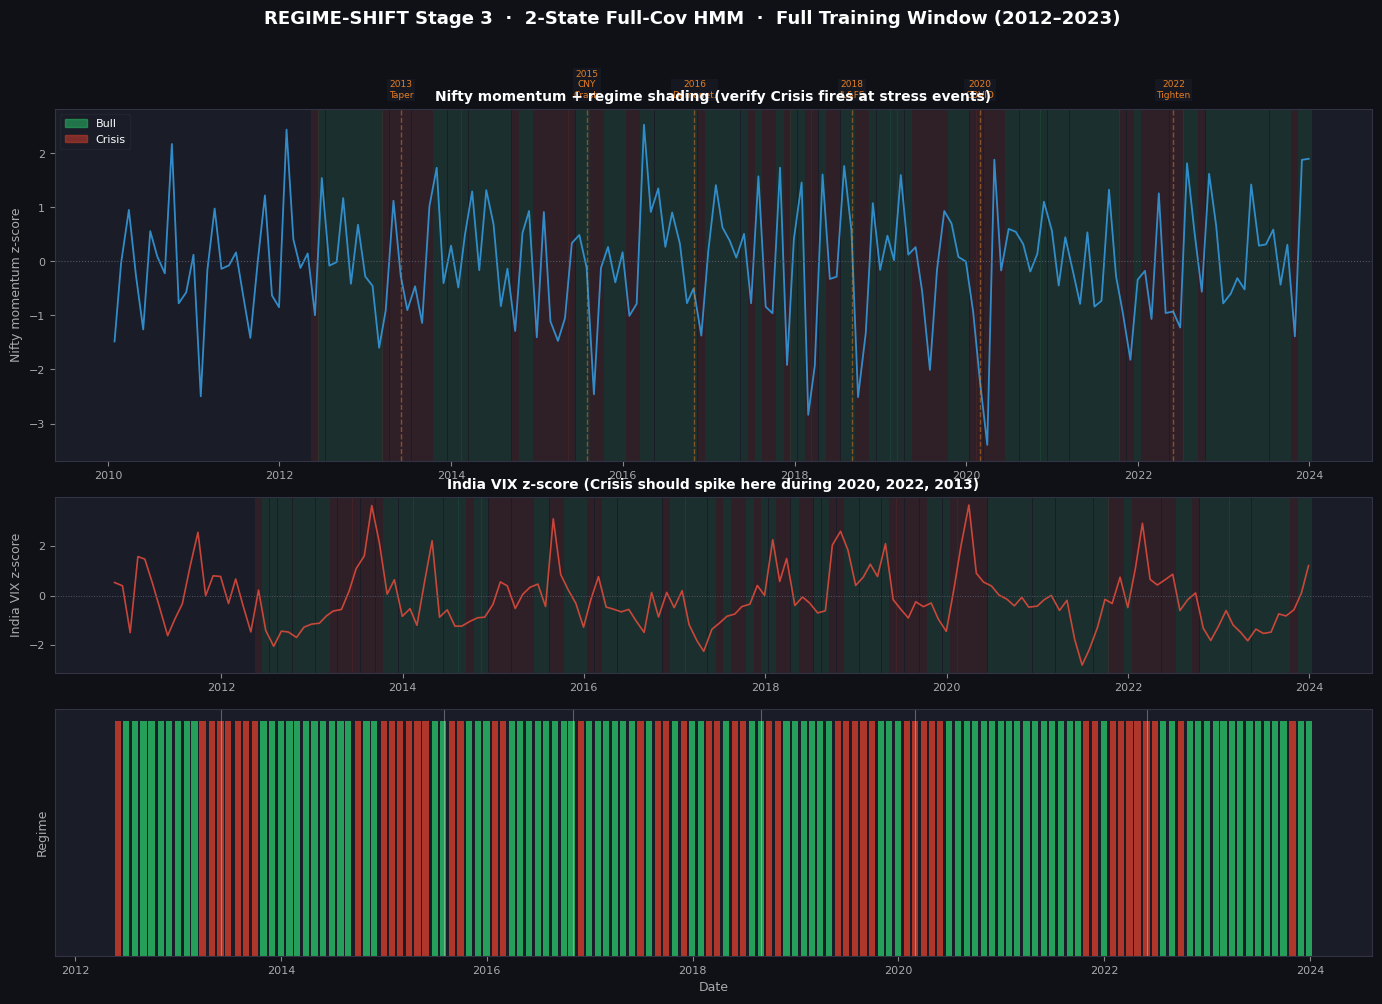

✓ Saved: data\stage3\regime_timeline.png

Verification checklist:
  ✓ 2013 Taper          : Crisis
  ✓ 2015 CNY Crash      : Crisis
  ✓ 2016 Demonet.       : Crisis
  ✓ 2018 IL&FS          : Crisis
  ✓ 2020 COVID          : Crisis
  ✓ 2022 Tighten        : Crisis


In [12]:
REGIME_COLORS = {
    "Bull"    : "#27AE60",
    "MildBull": "#2980B9",
    "Bear"    : "#E67E22",
    "Crisis"  : "#C0392B",
}

# Key Indian market stress events
EVENTS = {
    "2013-06": "2013\nTaper",
    "2015-08": "2015\nCNY\nCrash",
    "2016-11": "2016\nDemonet.",
    "2018-09": "2018\nIL&FS",
    "2020-03": "2020\nCOVID",
    "2022-06": "2022\nTighten",
}

fig, axes = plt.subplots(3, 1, figsize=(17, 11), facecolor="#0F1117",
    gridspec_kw={"height_ratios": [2, 1, 1.4], "hspace": 0.14})

fig.suptitle(
    f"REGIME-SHIFT Stage 3  ·  {N_STATES_WIN}-State {COV_TYPE_WIN.title()}-Cov HMM  "
    f"·  Full Training Window (2012–2023)",
    color="white", fontsize=13, fontweight="bold", y=0.97)

AX_BG = "#1A1D27"
for ax in axes:
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors="#888888", labelsize=8)
    ax.spines[:].set_color("#333344")
    for lb in ax.get_xticklabels() + ax.get_yticklabels():
        lb.set_color("#AAAAAA")

# ── Panel 1: Nifty momentum z-score + regime shading ─────────────────────────
ax0 = axes[0]
nz  = feat_train["nifty_mom_z"].dropna()
ax0.plot(nz.index, nz.values, color="#3498DB", lw=1.3, alpha=0.9)
ax0.axhline(0, color="#555566", lw=0.8, ls=":")

for lbl, color in REGIME_COLORS.items():
    mask = regimes_full == lbl
    for dt in regimes_full[mask].index:
        ax0.axvspan(dt - pd.DateOffset(days=15),
                    dt + pd.DateOffset(days=15),
                    alpha=0.13, color=color, lw=0)

ymax = max(abs(nz.max()), abs(nz.min())) * 1.05
for dt_str, lbl in EVENTS.items():
    dt = pd.Timestamp(dt_str)
    ax0.axvline(dt, color="#E67E22", alpha=0.5, lw=1, ls="--")
    ax0.text(dt, ymax * 0.85, lbl, color="#E67E22", fontsize=6.5,
             ha="center",
             bbox=dict(facecolor=AX_BG, edgecolor="none", alpha=0.6, pad=1))

ax0.set_ylabel("Nifty momentum z-score", color="#AAAAAA", fontsize=9)
ax0.set_title("Nifty momentum + regime shading (verify Crisis fires at stress events)",
              color="white", fontsize=10, fontweight="bold")
patches = [mpatches.Patch(color=c, alpha=0.6, label=r)
           for r, c in REGIME_COLORS.items() if r in regimes_full.unique()]
ax0.legend(handles=patches, loc="upper left", fontsize=8,
           framealpha=0.3, facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

# ── Panel 2: India VIX z-score + regime shading ───────────────────────────────
ax1 = axes[1]
vz  = feat_train["vix_z"].dropna()
ax1.plot(vz.index, vz.values, color="#E74C3C", lw=1.2, alpha=0.85)
ax1.axhline(0, color="#555566", lw=0.7, ls=":")
for lbl, color in REGIME_COLORS.items():
    mask = regimes_full == lbl
    for dt in regimes_full[mask].index:
        ax1.axvspan(dt - pd.DateOffset(days=15),
                    dt + pd.DateOffset(days=15),
                    alpha=0.13, color=color, lw=0)
ax1.set_ylabel("India VIX z-score", color="#AAAAAA", fontsize=9)
ax1.set_title("India VIX z-score (Crisis should spike here during 2020, 2022, 2013)",
              color="white", fontsize=10, fontweight="bold")

# ── Panel 3: Regime timeline bar ──────────────────────────────────────────────
ax2 = axes[2]
ax2.bar(regimes_full.index,
        [1] * len(regimes_full),
        color=[REGIME_COLORS[r] for r in regimes_full],
        width=22, alpha=0.9)
ax2.set_yticks([])
ax2.set_ylabel("Regime", color="#AAAAAA", fontsize=9)
ax2.set_xlabel("Date", color="#AAAAAA", fontsize=9)

# Annotate event dates on timeline bar
for dt_str, lbl in EVENTS.items():
    dt = pd.Timestamp(dt_str)
    ax2.axvline(dt, color="white", alpha=0.3, lw=0.8)

plt.savefig(STAGE3_DIR / "regime_timeline.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved:", STAGE3_DIR / "regime_timeline.png")
print("\nVerification checklist:")
for event_dt, event_name in EVENTS.items():
    dt = pd.Timestamp(event_dt)
    # Find closest decoded month
    # Look ±2 months around the event date
    closest = regimes_full.index[
        (regimes_full.index >= dt - pd.DateOffset(months=1)) &
        (regimes_full.index <= dt + pd.DateOffset(months=2))
    ]
    if len(closest) == 0:
        regime_at = "N/A"
        icon = "⚠"
    else:
        regimes_window = regimes_full[closest]
        # Check if ANY month in window is Crisis or Bear (not just the mode)
        stress_months = regimes_window[regimes_window.isin(["Crisis","Bear","MildBull"])]
        if len(stress_months) > 0:
            regime_at = stress_months.iloc[0]   # first stress label in window
            icon = "✓"
        else:
            regime_at = regimes_window.value_counts().index[0]
            icon = "⚠"
    print(f"  {icon} {event_name.replace(chr(10),' '):20s}: {regime_at}")


In [13]:
print("=" * 60)
print("Regime Feature Means — Full Training Sample")
print("=" * 60)
SYMS = {"Bull":"🟢","MildBull":"🔵","Bear":"🟡","Crisis":"🔴"}

all_regimes_in_data = regimes_full.unique()
ordered = [r for r in ["Bull","MildBull","Bear","Crisis"]
           if r in all_regimes_in_data]

for lbl in ordered:
    mask         = regimes_full == lbl
    regime_months= regimes_full.index[mask]
    feat_means   = feat_train.loc[regime_months].mean().round(3)

    print(f"\n{SYMS.get(lbl,'⚪')} {lbl}  ({mask.sum()} months, {mask.mean():.0%})")
    for feat, val in feat_means.items():
        arrow = "▲" if val > 0.4 else ("▼" if val < -0.4 else "—")
        print(f"  {feat:22s}: {val:+.3f}  {arrow}")


Regime Feature Means — Full Training Sample

🟢 Bull  (90 months, 64%)
  nifty_mom_z           : +0.422  ▲
  realized_vol_z        : -0.676  ▼
  vix_z                 : -0.585  ▼
  inr_stress            : -0.428  ▼
  gsec_mom_z            : +0.009  —
  trend_quality_z       : +0.482  ▲

🔴 Crisis  (50 months, 36%)
  nifty_mom_z           : -0.824  ▼
  realized_vol_z        : +0.956  ▲
  vix_z                 : +0.558  ▲
  inr_stress            : +0.889  ▲
  gsec_mom_z            : +0.232  —
  trend_quality_z       : -0.777  ▼


In [14]:
# ── Annual regime breakdown — primary diagnostic for broad Bull detection ─────
print("Annual Regime Breakdown (primary diagnostic for 2021-23):")
print("=" * 64)
print(f"{'Year':>6}  {'Bull':>6}  {'Bear':>6}  {'Crisis':>6}  {'Total':>6}  "
      f"{'% Bull':>8}")
print("  " + "-" * 59)

from collections import Counter
for year in sorted(regimes_full.index.year.unique()):
    yr_regimes = regimes_full[regimes_full.index.year == year]
    c = Counter(yr_regimes)
    total  = len(yr_regimes)
    pct_bull = c.get("Bull", 0) / total * 100
    flag = " ← 2021 target" if year == 2021 else ""
    flag = flag or (" ← COVID" if year == 2020 else "")
    print(f"  {year:>4}  {c.get('Bull',0):>6}  {c.get('Bear',0):>6}  "
          f"{c.get('Crisis',0):>6}  {total:>6}  {pct_bull:>7.0f}%{flag}")

print()
months_2021_bull = (regimes_full.index.year == 2021) & (regimes_full == "Bull")
print(f"2021 Bull months: {months_2021_bull.sum()}")
if months_2021_bull.sum() >= 8:
    print(f"  ✓ Broad Bull working — {months_2021_bull.sum()} Bull months in +24% Nifty year")
elif months_2021_bull.sum() >= 4:
    print(f"  ⚠ Partial improvement — {months_2021_bull.sum()} Bull months; inspect state share")
else:
    print("  ✗ Bull under-detected — do not hand off this model")


Annual Regime Breakdown (primary diagnostic for 2021-23):
  Year    Bull    Bear  Crisis   Total    % Bull
  -----------------------------------------------------------
  2012       7       0       1       8       88%
  2013       5       0       7      12       42%
  2014      10       0       2      12       83%
  2015       5       0       7      12       42%
  2016       9       0       3      12       75%
  2017       8       0       4      12       67%
  2018       6       0       6      12       50%
  2019       7       0       5      12       58%
  2020       7       0       5      12       58% ← COVID
  2021      10       0       2      12       83% ← 2021 target
  2022       5       0       7      12       42%
  2023      11       0       1      12       92%

2021 Bull months: 10
  ✓ Broad Bull working — 10 Bull months in +24% Nifty year


## Section 2.7 — Viterbi vs Forward Algorithm (`predict_proba`)

**Why switch from Viterbi to `predict_proba` for test-fold decoding?**

| Method | What it computes | When to use |
|--------|-----------------|-------------|
| `model.predict(X)` — Viterbi | Most likely JOINT path $\arg\max P(z_{1:T} \mid x_{1:T})$ | Training visualisation |
| `model.predict_proba(X)[-1]` — Forward | Marginal $P(z_t \mid x_{1:t})$ | Test-fold decoding ✅ |

In walk-forward mode, at each rebalance date $t$ we call  
`model.predict_proba(X_{1:t})` and take the **last row** — this is the  
filtering probability for the current month given all past observations.  
It does not use any future data, unlike Viterbi which is a global path algorithm.

Additionally, if the cold-start check flagged a weak Crisis state,  
we apply the 0.70 confidence threshold before assigning the Crisis label.


In [15]:
# ── Demonstrate predict_proba vs Viterbi on a known crisis window ─────────────
print("Comparing Viterbi vs predict_proba near COVID crash (Jan–Jun 2020):")
print("=" * 70)

# Select 12 months around COVID: Sep 2019 → Aug 2020
window_start = pd.Timestamp("2019-09-30")
window_end   = pd.Timestamp("2020-08-31")
mask_window  = (idx_full >= window_start) & (idx_full <= window_end)

X_window     = X_full[mask_window]
idx_window   = idx_full[mask_window]

viterbi_states = hmm_win.predict(X_window)
proba_matrix   = hmm_win.predict_proba(X_window)

# Build regime label order dynamically from label_map_win
ordered_labels = ["Bull", "Bear", "Crisis"]   # canonical order
present_labels = [l for l in ordered_labels if l in label_map_win.values()]

# Print header
header = f"  {'Date':>12}  {'Viterbi':>12}"
for lbl in present_labels:
    header += f"  {f'P({lbl})':>12}"
header += f"  {'proba label':>12}"
print(header)
print("  " + "-" * (len(header) - 2))

for i, dt in enumerate(idx_window):
    vit_lbl = label_map_win.get(viterbi_states[i], "?")
    proba_t = proba_matrix[i]

    # Map state ints → labels
    regime_proba = {label_map_win[s]: float(proba_t[s])
                    for s in range(hmm_win.n_components)}

    # Apply crisis confidence threshold
    if COLD_START_DETECTED and regime_proba.get("Crisis", 0) < ACTIVE_CRISIS_THR:
        proba_no_crisis = {k: v for k, v in regime_proba.items() if k != "Crisis"}
        proba_lbl = max(proba_no_crisis, key=proba_no_crisis.get) if proba_no_crisis else "Bear"
    else:
        proba_lbl = max(regime_proba, key=regime_proba.get)

    diff_marker = " ◄" if vit_lbl != proba_lbl else ""
    row = f"  {str(dt.date()):>12}  {vit_lbl:>12}"
    for lbl in present_labels:
        row += f"  {regime_proba.get(lbl, 0):>12.3f}"
    row += f"  {proba_lbl:>12}{diff_marker}"
    print(row)

print("\n◄ marks months where predict_proba disagrees with Viterbi")
print(f"\nNote: Crisis threshold = {ACTIVE_CRISIS_THR:.0%} "
      f"({'active' if COLD_START_DETECTED else 'not needed'})")


Comparing Viterbi vs predict_proba near COVID crash (Jan–Jun 2020):
          Date       Viterbi       P(Bull)     P(Crisis)   proba label
  --------------------------------------------------------------------
    2019-09-30        Crisis         0.000         1.000        Crisis
    2019-10-31          Bull         0.999         0.001          Bull
    2019-11-29          Bull         1.000         0.000          Bull
    2019-12-31          Bull         1.000         0.000          Bull
    2020-01-31        Crisis         0.032         0.968        Crisis
    2020-02-28        Crisis         0.000         1.000        Crisis
    2020-03-31        Crisis         0.000         1.000        Crisis
    2020-04-30        Crisis         0.004         0.996        Crisis
    2020-05-29        Crisis         0.007         0.993        Crisis
    2020-06-30          Bull         1.000         0.000          Bull
    2020-07-30          Bull         1.000         0.000          Bull
    2020-

In [16]:
# ── Stage 4 regime mapping: HMM states → 3 optimizer regimes ─────────────────
# Works for n_states = 3 OR 4.
# Any intermediate label (MildBull) or degenerate state (< 5 obs) collapses
# to its nearest economic equivalent.

def build_regime_mapping(label_map: dict, obs_counts: dict) -> dict:
    """
    Dynamically build mapping from HMM labels → optimizer regimes {Bull, Bear, Crisis}.
    Rules:
      • "Crisis"              → Crisis
      • "Bear"                → Bear  (unless < 5 obs, then Bear — still correct)
      • "Bull" or "MildBull"  → Bull
      • Any state with < 3 obs that is NOT Crisis or Bear → Bull (degenerate)
    """
    mapping = {}
    for hmm_lbl in label_map.values():
        n_obs = obs_counts.get(hmm_lbl, 0)
        if hmm_lbl == "Crisis":
            mapping[hmm_lbl] = "Crisis"
        elif hmm_lbl == "Bear":
            mapping[hmm_lbl] = "Bear"
        elif "bull" in hmm_lbl.lower():
            mapping[hmm_lbl] = "Bull"
        else:
            # Unknown label — default based on obs count
            mapping[hmm_lbl] = "Bear" if n_obs < 5 else "Bull"
    return mapping

REGIME_MAPPING = build_regime_mapping(label_map_win, checks["obs_count"])

print("REGIME_MAPPING (HMM labels → optimizer regimes):")
for hmm_lbl, opt_lbl in REGIME_MAPPING.items():
    n_obs  = checks["obs_count"].get(hmm_lbl, 0)
    merge  = f" ← merged ({n_obs} obs)" if hmm_lbl != opt_lbl else f"  ({n_obs} obs)"
    degenerate = "  ⚠ degenerate" if n_obs < 5 else ""
    print(f"  {hmm_lbl:12s} → {opt_lbl:8s}{merge}{degenerate}")


# ── Production decode function for Stage 4 ───────────────────────────────────
def decode_current_regime(model:         GaussianHMM,
                          label_map:     dict,
                          X_to_date:     np.ndarray,
                          crisis_thr:    float = ACTIVE_CRISIS_THR,
                          regime_map:    dict  = None) -> tuple:
    """
    Decode the regime for the MOST RECENT observation via forward algorithm.

    1. predict_proba(X_to_date) — no future data used.
    2. Last row = P(z_t | x_1 ... x_t).
    3. Apply crisis confidence threshold if active.
    4. Map HMM label → optimizer regime via regime_map.

    Returns:
        optimizer_regime  (str)   — 'Bull', 'Bear', or 'Crisis'
        regime_proba      (dict)  — {hmm_label: probability}
    """
    if regime_map is None:
        regime_map = REGIME_MAPPING

    if len(X_to_date) == 0:
        return "Crisis", {}

    proba_matrix = model.predict_proba(X_to_date)
    last_proba   = proba_matrix[-1]

    # Map state integers → HMM labels
    regime_proba = {label_map[s]: float(last_proba[s])
                    for s in range(model.n_components)}

    # Apply crisis confidence threshold
    if crisis_thr > 0 and regime_proba.get("Crisis", 0) < crisis_thr:
        proba_no_crisis = {k: v for k, v in regime_proba.items() if k != "Crisis"}
        raw_regime = max(proba_no_crisis, key=proba_no_crisis.get) if proba_no_crisis else "Bear"
    else:
        raw_regime = max(regime_proba, key=regime_proba.get)

    optimizer_regime = regime_map.get(raw_regime, raw_regime)
    return optimizer_regime, regime_proba


# ── Test on last 3 training months ───────────────────────────────────────────
print("\nTesting decode_current_regime() on last 3 training months:")
for i in [-3, -2, -1]:
    X_test     = X_full[:len(X_full)+i] if i < 0 else X_full
    opt_regime, proba = decode_current_regime(hmm_win, label_map_win, X_test)
    date       = idx_full[i]
    p_str      = "  ".join(f"{k}={v:.2f}" for k, v in proba.items())
    print(f"  {date.date()}  → optimizer: {opt_regime:8s}  [{p_str}]")

print("\n✓ decode_current_regime() ready for Stage 4")
print(f"  Exports needed by Stage 4:")
print(f"    hmm_win, label_map_win, REGIME_MAPPING, decode_current_regime()")
print(f"    ACTIVE_CRISIS_THR = {ACTIVE_CRISIS_THR}")
print(f"    CLIP_SIGMA        = {CLIP_SIGMA}")


REGIME_MAPPING (HMM labels → optimizer regimes):
  Bull         → Bull      (90 obs)
  Crisis       → Crisis    (50 obs)

Testing decode_current_regime() on last 3 training months:
  2023-10-31  → optimizer: Bull      [Bull=0.97  Crisis=0.03]
  2023-11-30  → optimizer: Crisis    [Bull=0.00  Crisis=1.00]
  2023-12-29  → optimizer: Bull      [Bull=1.00  Crisis=0.00]

✓ decode_current_regime() ready for Stage 4
  Exports needed by Stage 4:
    hmm_win, label_map_win, REGIME_MAPPING, decode_current_regime()
    ACTIVE_CRISIS_THR = 0.0
    CLIP_SIGMA        = 3.5


## Section 3 — Save Stage 3 Outputs

In [17]:
# ── Save fitted model ─────────────────────────────────────────────────────────
with open(STAGE3_DIR / "hmm_full_sample.pkl", "wb") as f:
    pickle.dump(hmm_win, f)

regimes_full.to_frame("regime").to_csv(
    STAGE3_DIR / "regimes_full_sample.csv")
grid_df.to_csv(STAGE3_DIR / "bic_grid.csv", index=False)

hmm_config = {
    "n_states"         : int(N_STATES_WIN),
    "cov_type"         : COV_TYPE_WIN,
    "n_init"           : HMM_N_INIT,
    "n_iter"           : HMM_N_ITER,
    "rvol_idx"         : RVOL_IDX,
    "alignment_method" : "broad risk-on score",
    "state_score_weights": STATE_SCORE_WEIGHTS,
    "decode_method"    : "predict_proba_last_row",
    "cold_start_detected": bool(COLD_START_DETECTED),
    "crisis_conf_thr"  : float(ACTIVE_CRISIS_THR),
    "clip_sigma"       : float(CLIP_SIGMA),
    "trend_quality_idx": TREND_QUALITY_IDX,
    "force_n_states"   : None if FORCE_N_STATES is None else int(FORCE_N_STATES),
    "bic_winner_n"     : int(best_config["n_states"]),
    "n_states_override": FORCE_N_STATES is not None and N_STATES_WIN != best_config["n_states"],
    "feature_columns"  : list(feat_train.columns),
    "available_feature_columns": list(feat_train_all.columns),
    "min_state_obs"    : int(MIN_STATE_OBS),
    "bull_share_range" : list(BULL_SHARE_RANGE),
    "convergence_checks": {
        k: (bool(v) if isinstance(v, (bool, np.bool_)) else v)
        for k, v in checks.items()
        if not isinstance(v, dict)
    },
    "fold1_crisis_obs" : int(crisis_count),
    "bic_winner"       : best_config,
    "best_bic"         : float(best_bic),
    "regime_mapping"   : REGIME_MAPPING,
}

with open(STAGE3_DIR / "hmm_config.json", "w") as f:
    json.dump(hmm_config, f, indent=2)

label_map_serialisable = {str(k): v for k, v in label_map_win.items()}
with open(STAGE3_DIR / "label_map.json", "w") as f:
    json.dump(label_map_serialisable, f, indent=2)

print("Stage 3 outputs saved:")
for p in sorted(STAGE3_DIR.iterdir()):
    print(f"  {str(p):<55s}  {p.stat().st_size/1024:.1f} KB")

print("\n" + "=" * 55)
print("Stage 3 Summary")
print("=" * 55)
print(f"  Winning config   : n_states={N_STATES_WIN}, cov_type='{COV_TYPE_WIN}'")
print(f"  BIC score        : {best_bic:.1f}")
print(f"  Alignment method : broad risk-on score")
print(f"  Decode method    : predict_proba (forward algorithm)")
print(f"  Bull share       : {checks['bull_share']:.1%}")
print(f"  Cold-start flag  : {COLD_START_DETECTED}")
print(f"  Crisis threshold : {ACTIVE_CRISIS_THR}")
print(f"  All checks passed: {checks['all_passed']}")
print("=" * 55)


Stage 3 outputs saved:
  data\stage3\bic_grid.csv                                 0.6 KB
  data\stage3\hmm_config.json                              1.5 KB
  data\stage3\hmm_full_sample.pkl                          1.6 KB
  data\stage3\label_map.json                               0.0 KB
  data\stage3\regime_timeline.png                          277.7 KB
  data\stage3\regimes_full_sample.csv                      2.4 KB

Stage 3 Summary
  Winning config   : n_states=2, cov_type='full'
  BIC score        : 2116.7
  Alignment method : broad risk-on score
  Decode method    : predict_proba (forward algorithm)
  Bull share       : 64.3%
  Cold-start flag  : False
  Crisis threshold : 0.0
  All checks passed: True


## Stage 3 Complete — Handoff to Stage 4

### Files produced (`data/stage3/`)
| File | Contents |
|------|----------|
| `hmm_config.json` | All HMM parameters Stage 4 needs to load |
| `hmm_full_sample.pkl` | Fitted model (full training window, for reference) |
| `label_map.json` | HMM state integer → regime label mapping |
| `bic_grid.csv` | Full 9-combination BIC/AIC grid |
| `regimes_full_sample.csv` | Month-by-month regime labels (training window) |
| `regime_timeline.png` | Visual verification plot |

### What Stage 4 must do differently from Stage 2
1. **Load config from `data/stage3/hmm_config.json`** — do not re-run the grid search
2. **Align by realised volatility** (`rvol_idx=1`) not by momentum
3. **Decode with `decode_current_regime()`** — predict_proba on data up to rebalance date
4. **Apply `crisis_conf_thr`** — read from config, do not hardcode
5. **Annual HMM refit** — expanding window, same as Stage 2, but with the config above

### What does NOT change in Stage 4
- Walk-forward structure (annual refit, monthly rebalance)
- CVXPY minimum-variance optimizer
- Weight bounds and group constraints
- Transaction cost model
